## Web Scraping and Charts in Python

In this exercise, I used webscraping to create DataFrames from HTML and created tables/visualizations of the data. 


## Setup

In [6]:
import numpy as np               # Arrays and matrix functions
import pandas as pd              # Data frames and functions
import matplotlib.pyplot as plt  # Plots
import seaborn as sns
import json                      # Working with JSON data
import requests                  # Fetching data online
from bs4 import BeautifulSoup    # Working with HTML pages

## 1 Scrape web data

Use the requests library to fetch the web page at the URL below, which contains a list of the US State department's travel recommendations. Then extract the content from that request and store it as a Python object.



In [7]:
# US state department travel advisories
url='https://travel.state.gov/content/travel/en/traveladvisories/traveladvisories.html/'


## 2 Inspect the results

Use BeautifulSoup to parse the web page we fetched into a somewhat readable, JSON-like tree of data. Look at this tree for the location of the information on threat levels by country.



In [8]:
r = requests.get(url)
soup = BeautifulSoup(r.content, "html.parser")
table = soup.find('table')
for country in table.find_all('tbody'):
    rows = country.find_all('tr', scope = False)

rows

[<tr data-date="10/16/23">
 <td><a href="/content/travel/en/traveladvisories/traveladvisories/israel-west-bank-and-gaza-travel-advisory.html" title="Israel, the West Bank and Gaza Travel Advisory ">Israel, the West Bank and Gaza Travel Advisory </a></td>
 <td>Other</td>
 <td>October 14, 2023</td>
 </tr>,
 <tr data-date="7/26/23">
 <td><a href="/content/travel/en/traveladvisories/traveladvisories/Liechtenstein-Travel-Advisory.html" title="Liechtenstein Travel Advisory">Liechtenstein Travel Advisory</a></td>
 <td>Level 1: Exercise Normal Precautions</td>
 <td>July 26, 2023</td>
 </tr>,
 <tr data-date="7/26/23">
 <td><a href="/content/travel/en/traveladvisories/traveladvisories/north-macedonia-travel-advisory.html" title="North Macedonia Travel Advisory">North Macedonia Travel Advisory</a></td>
 <td>Level 1: Exercise Normal Precautions</td>
 <td>July 26, 2023</td>
 </tr>,
 <tr data-date="7/24/23">
 <td><a href="/content/travel/en/traveladvisories/traveladvisories/nauru-travel-advisory.htm

## 3 explore table structure

Use `.find_all()` and `.string` to find the combinations that return string values for the country of the travel advisory, the level of the threat, and the date the US state dept posted its threat assessment. 


In [9]:
#Find Specific Country Name - North Macedonia for example
Country = soup.find_all('tr')[2].find_all('td')[0].string.split('Travel')[0]
Country


'Liechtenstein '

In [10]:
#Find Specific Level of Threat - North Macedonia for example
Threat = soup.find_all('tr')[2].find_all('td')[1].string
Threat

'Level 1: Exercise Normal Precautions'

In [11]:
#Find date the US state dept posted its threat assessment - North Macedonia for example
PostedDate = soup.find_all('tr')[2].find_all('td')[2].string
PostedDate

'July 26, 2023'

In [12]:
#Find All Country Names
CountryColumn = []
for row in rows:
    Name = row.find_all('td')[0].string.split(' Travel')[0]
    CountryColumn.append(Name)

CountryColumndf = pd.DataFrame(CountryColumn, columns = ['Country'])
CountryColumndf

,Country
0,"Israel, the West Bank and Gaza"
1,Liechtenstein
2,North Macedonia
3,Nauru
4,Palau
...,...
207,Republic of the Congo
208,Guinea-Bissau
209,Bonaire
210,Sint Eustatius


In [13]:
#Find All Threat Levels
ThreatColumn = []
for row in rows:
    Threat = row.find_all('td')[1].string
    ThreatColumn.append(Threat)

ThreatColumndf = pd.DataFrame(ThreatColumn, columns = ['Threat Level'])
ThreatColumndf

,Threat Level
0,Other
1,Level 1: Exercise Normal Precautions
2,Level 1: Exercise Normal Precautions
3,Level 1: Exercise Normal Precautions
4,Level 1: Exercise Normal Precautions
...,...
207,Level 2: Exercise Increased Caution
208,Level 3: Reconsider Travel
209,Level 1: Exercise Normal Precautions
210,Level 1: Exercise Normal Precautions


In [14]:
#Find All Posted Dates
DateColumn = []
for row in rows:
    Date = row.find_all('td')[2].string
    DateColumn.append(Date)
    
DateColumndf = pd.DataFrame(DateColumn, columns = ['Posted Date'])
DateColumndf

,Posted Date
0,"October 14, 2023"
1,"July 26, 2023"
2,"July 26, 2023"
3,"July 24, 2023"
4,"July 24, 2023"
...,...
207,"July 31, 2023"
208,"July 31, 2023"
209,"July 17, 2023"
210,"October 16, 2023"


## 4 Export table to dataframe

Navigate the soup object to get the names of each country, the level of the threat, and the date of the notice. Turn this into a data frame with column headings. Convert the strings for each country name to report only the name of the country, and change the strings for the warning levels into a numerical data item numbered 1 through 4.



In [15]:
#Change Threat Level to number 
ThreatNumberColumn = []
for row in rows:
    ThreatNumber = row.find_all('td')[1].string.split(":")[0]
    ThreatNumberColumn.append(ThreatNumber)

ThreatNumberColumndf = pd.DataFrame(ThreatNumberColumn, columns = ['Threat Level (#)'])
ThreatNumberColumndf = ThreatNumberColumndf.replace('Caution','Level 2')
splitted = ThreatNumberColumndf['Threat Level (#)'].str.split(" ", n=1, expand = True)
ThreatNumberColumndf['Threat Level (#)'] = splitted[1]
ThreatNumberColumndf['Threat Level (#)'] = pd.to_numeric(ThreatNumberColumndf['Threat Level (#)'])
ThreatNumberColumndf


,Threat Level (#)
0,NaN
1,1.0
2,1.0
3,1.0
4,1.0
...,...
207,2.0
208,3.0
209,1.0
210,1.0


In [16]:
#Join into single dataframe
df = CountryColumndf.join(ThreatNumberColumndf.join(DateColumndf))
df

,Country,Threat Level (#),Posted Date
0,"Israel, the West Bank and Gaza",NaN,"October 14, 2023"
1,Liechtenstein,1.0,"July 26, 2023"
2,North Macedonia,1.0,"July 26, 2023"
3,Nauru,1.0,"July 24, 2023"
4,Palau,1.0,"July 24, 2023"
...,...,...,...
207,Republic of the Congo,2.0,"July 31, 2023"
208,Guinea-Bissau,3.0,"July 31, 2023"
209,Bonaire,1.0,"July 17, 2023"
210,Sint Eustatius,1.0,"October 16, 2023"


## 5 Fetch, parse and merge using additional data

Build database of country characteristics from three differrent data sources. 

In [17]:
# GDP and population aggregates by country.
url2='https://www.worldometers.info/gdp/gdp-by-country/'

In [18]:
# Get the worldometer GDP data
response2 = requests.get(url2)
webpage2 = response2.content


In [19]:
# Make some soup
soup2 = BeautifulSoup(response2.content, 
            "html.parser")

# Look at the soup
soup2


<!DOCTYPE html>
<!--[if IE 8]> <html lang="en" class="ie8"> <![endif]--><!--[if IE 9]> <html lang="en" class="ie9"> <![endif]--><!--[if !IE]><!--> <html lang="en"> <!--<![endif]--> <head> <meta charset="utf-8"/> <meta content="IE=edge" http-equiv="X-UA-Compatible"/> <meta content="width=device-width, initial-scale=1" name="viewport"/> <title>GDP by Country - Worldometer</title><meta content="Countries in the world ranked by Gross Domestic Product (GDP). List and ranking of GDP growth, GDP per capita and couuntry share of World's GDP" name="description"/><!-- Favicon --><link href="/favicon/favicon.ico" rel="shortcut icon" type="image/x-icon"/><link href="/favicon/apple-icon-57x57.png" rel="apple-touch-icon" sizes="57x57"/><link href="/favicon/apple-icon-60x60.png" rel="apple-touch-icon" sizes="60x60"/><link href="/favicon/apple-icon-72x72.png" rel="apple-touch-icon" sizes="72x72"/><link href="/favicon/apple-icon-76x76.png" rel="apple-touch-icon" sizes="76x76"/><link href="/favicon/app

In [20]:
# Store the number of rows using len() for future looping
number_of_rows2=len(soup2.find_all('tr'))

In [21]:
# Find the country name by navigating the tree using chaned .find_all()s and .string()
soup2.find_all('tr')[2].find_all('td')[1].string

'China'

In [22]:
# Find total GDP
soup2.find_all('tr')[2].find_all('td')[2].string

'$17,963,200,000,000'

In [23]:
# Find total population
soup2.find_all('tr')[2].find_all('td')[5].string

'1,425,887,337'

In [24]:
# Find GDP per capita
soup2.find_all('tr')[2].find_all('td')[6].string

'$12,598'

In [25]:
# Create an array to store the retreived values
cleaned_values2=np.empty((number_of_rows2,4), dtype='object')

In [26]:
# Navigate the soup object and add values for country name, GDP, population, and GDP
# per captia to the array.

for x in range(1,number_of_rows2):
    row=x-1
    cleaned_values2[row,0] = soup2.find_all('tr')[x].find_all('td')[1].string
    cleaned_values2[row,1] = soup2.find_all('tr')[x].find_all('td')[2].string
    cleaned_values2[row,2] = soup2.find_all('tr')[x].find_all('td')[5].string
    cleaned_values2[row,3] = soup2.find_all('tr')[x].find_all('td')[6].string
    
cleaned_values2    

array([['United States', '$25,462,700,000,000', '338,289,857', '$75,269'],
       ['China', '$17,963,200,000,000', '1,425,887,337', '$12,598'],
       ['Japan', '$4,231,140,000,000', '123,951,692', '$34,135'],
       ['Germany', '$4,072,190,000,000', '83,369,843', '$48,845'],
       ['India', '$3,385,090,000,000', '1,417,173,173', '$2,389'],
       ['United Kingdom', '$3,070,670,000,000', '67,508,936', '$45,485'],
       ['France', '$2,782,910,000,000', '64,626,628', '$43,061'],
       ['Russia', '$2,240,420,000,000', '144,713,314', '$15,482'],
       ['Canada', '$2,139,840,000,000', '38,454,327', '$55,646'],
       ['Italy', '$2,010,430,000,000', '59,037,474', '$34,053'],
       ['Brazil', '$1,920,100,000,000', '215,313,498', '$8,918'],
       ['Australia', '$1,675,420,000,000', '26,177,413', '$64,003'],
       ['South Korea', '$1,665,250,000,000', '51,815,810', '$32,138'],
       ['Mexico', '$1,414,190,000,000', '127,504,125', '$11,091'],
       ['Spain', '$1,397,510,000,000', '47,55

In [27]:
# Convert these cleaned values to a data frame, adding column headings.

df2=pd.DataFrame(cleaned_values2, columns=['Country','gdp_raw','pop_raw','gdp_percap_raw'])

df2

,Country,gdp_raw,pop_raw,gdp_percap_raw
0,United States,"$25,462,700,000,000","338,289,857","$75,269"
1,China,"$17,963,200,000,000","1,425,887,337","$12,598"
2,Japan,"$4,231,140,000,000","123,951,692","$34,135"
3,Germany,"$4,072,190,000,000","83,369,843","$48,845"
4,India,"$3,385,090,000,000","1,417,173,173","$2,389"
...,...,...,...,...
173,Micronesia,"$427,094,119","539,013",$792
174,Marshall Islands,"$279,667,900","41,569","$6,728"
175,Kiribati,"$223,352,943","131,232","$1,702"
176,Tuvalu,"$60,349,391","11,312","$5,335"


In [28]:
# Convert to numeric format. However, .to_numeric() will fail if it sees
# anything that's not a number, including dollar signs and punctuation. Use .str.replace()
# to get rid of the extra characters, then use .to_numeric to convert these data

df2['gdp']=(df2['gdp_raw']
             .str.replace('$','', regex=False)
             .str.replace(',','')
            )

df2['pop']=(df2['pop_raw']
             .str.replace(',','')
            )


df2['gdp_percap']=(df2['gdp_percap_raw']
             .str.replace('$','')
             .str.replace(',','', regex=False)
            )

df2['gdp']=pd.to_numeric(df2['gdp'],errors='coerce')/1_000_000_000
df2['pop']=pd.to_numeric(df2['pop'],errors='coerce')/1_000_000
df2['gdp_percap']=pd.to_numeric(df2['gdp_percap'],errors='coerce')

In [29]:
# Inspect the GDP data.
df2 = df2.drop(columns=['gdp_raw','pop_raw','gdp_percap_raw'])
df2

,Country,gdp,pop,gdp_percap
0,United States,25462.700000,338.289857,75269.0
1,China,17963.200000,1425.887337,12598.0
2,Japan,4231.140000,123.951692,34135.0
3,Germany,4072.190000,83.369843,48845.0
4,India,3385.090000,1417.173173,2389.0
...,...,...,...,...
173,Micronesia,0.427094,0.539013,792.0
174,Marshall Islands,0.279668,0.041569,6728.0
175,Kiribati,0.223353,0.131232,1702.0
176,Tuvalu,0.060349,0.011312,5335.0


In [30]:
# Use 'location' as the index for both data frames.
df2=df2.set_index('Country')
df=df.set_index('Country')

In [31]:
# This is a little dictionary to make sure countries are consistently named in our dataframes.
rename_dict={'Russian Federation':'Russia',
            'Czechia':'Czech Republic',
           'Czech Republic (Czechia)':'Czech Republic',
            'Burma (Myanmar)':'Myanmar',
            'Syrian Arab Republic':'Syria',
            'United States of America':'United States',
            'China, Hong Kong SAR':'Hong Kong'
    }

In [32]:
# Use 'rename_dict' with .rename() to ensure consistent names for countries.
# Otherwise, the join operation will think we don't have a match.
df=df.rename(rename_dict, axis='index')
df2=df2.rename(rename_dict, axis='index')

In [33]:
# Merge the GDP and threat-level data sets. Use the 'inner' method to only keep countries where we have both
# data items.
df_both=df.join(df2, how='inner')

In [34]:
# Inspect the combined dataset
df_both

,Threat Level (#),Posted Date,gdp,pop,gdp_percap
Country,,,,,
North Macedonia,1.0,"July 26, 2023",13.563132,2.093599,6478.0
Myanmar,4.0,"July 24, 2023",59.364363,54.179306,1096.0
Albania,2.0,"July 26, 2023",18.882096,2.842321,6643.0
Algeria,2.0,"July 13, 2023",191.913000,44.903225,4274.0
Andorra,1.0,"July 26, 2023",3.352033,0.079824,41993.0
...,...,...,...,...,...
Ethiopia,3.0,"July 31, 2023",126.783000,123.379924,1028.0
Gabon,2.0,"September 28, 2023",21.071739,2.388992,8820.0
Georgia,1.0,"July 26, 2023",24.605375,3.744385,6571.0


In [37]:
# Request the data on homicides from the United Nations
url3='https://dataunodc.un.org/sites/dataunodc.un.org/files/homicide_country_download.xlsx'

# Read the data file from Excel format
df_homicides=pd.read_excel(url3)

In [38]:
# See what the data look like
df_homicides

,Region,Subregion,country,iso3_code,Indicator,Disaggregation,Gender,Source,Unit,Year,Value,Footnote
0,Asia,Southern Asia,Afghanistan,AFG,Homicide: # of victims,-,Total (all ages),NSO,Count,2009,1115,NaN
1,Asia,Southern Asia,Afghanistan,AFG,Homicide: # of victims,-,Total (all ages),NSO,"Rate per 100,000 population",2009,3.93,NaN
2,Asia,Southern Asia,Afghanistan,AFG,Homicide: # of victims,-,Total (all ages),NSO,Count,2010,983,NaN
3,Asia,Southern Asia,Afghanistan,AFG,Homicide: # of victims,-,Total (all ages),NSO,"Rate per 100,000 population",2010,3.37,NaN
4,Asia,Southern Asia,Afghanistan,AFG,Homicide: # of victims,-,Total (all ages),NSO,Count,2011,1231,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
24387,Africa,Sub-Saharan Africa,Zimbabwe,ZWE,Homicide: # of victims,-,Total (all ages),WHO,"Rate per 100,000 population",2006,8.82,NaN
24388,Africa,Sub-Saharan Africa,Zimbabwe,ZWE,Homicide: # of victims,-,Total (all ages),WHO,Count,2010,711,NaN
24389,Africa,Sub-Saharan Africa,Zimbabwe,ZWE,Homicide: # of victims,-,Total (all ages),WHO,"Rate per 100,000 population",2010,5.6,NaN
24390,Africa,Sub-Saharan Africa,Zimbabwe,ZWE,Homicide: # of victims,-,Total (all ages),WHO,Count,2012,981,NaN


In [39]:
# Mask to keep the all-gender data
df_homicides=(df_homicides[(df_homicides['Gender']=="Total (all ages)")] )

# Mask to keep the data structured as homicide rates
df_homicides=(df_homicides[(df_homicides['Unit']=="Rate per  100,000 population")]) 

In [40]:
# Sort the homicide data and discard all observations except the most recent
df_homicides=(df_homicides
              .sort_values(['country','Year','Value']) # Sort by country, then by year, then by Value
              .groupby('country')                      # Group on country
              .last()                                  # Keep the last observation in each country, which
            )                                          #  is the most recent one after sorting.
                

In [41]:
# Look at the homicide data
df_homicides

,Region,Subregion,iso3_code,Indicator,Disaggregation,Gender,Source,Unit,Year,Value,Footnote
country,,,,,,,,,,,
Afghanistan,Asia,Southern Asia,AFG,Homicide: # of victims,-,Total (all ages),NSO,"Rate per 100,000 population",2018,6.66,None
Albania,Europe,Southern Europe,ALB,Homicide: # of victims,-,Total (all ages),Covid-19,"Rate per 100,000 population",2020,2.12,None
Algeria,Africa,Northern Africa,DZA,Homicide: # of victims,-,Total (all ages),External,"Rate per 100,000 population",2020,1.32,None
American Samoa,Oceania,Polynesia,ASM,Homicide: # of victims,-,Total (all ages),External,"Rate per 100,000 population",2019,0,None
Andorra,Europe,Southern Europe,AND,Homicide: # of victims,-,Total (all ages),CTS,"Rate per 100,000 population",2020,2.59,None
...,...,...,...,...,...,...,...,...,...,...,...
Venezuela (Bolivarian Republic of),Americas,Latin America and the Caribbean,VEN,Homicide: # of victims,-,Total (all ages),CTS,"Rate per 100,000 population",2017,49.88,None
Viet Nam,Asia,South-eastern Asia,VNM,Homicide: # of victims,-,Total (all ages),WHO,"Rate per 100,000 population",2011,1.53,None
Yemen,Asia,Western Asia,YEM,Homicide: # of victims,-,Total (all ages),NSO,"Rate per 100,000 population",2013,6.77,None


In [42]:
# Clean up the homicides data 
df_homicides=(df_homicides
              .reset_index()
              .loc[:,['country', 'iso3_code','Value']]
              .rename(columns={'Value':'homicide_rate', 'country':'Country'})
              .set_index('Country')
              .rename(rename_dict, axis='index')
             )


In [43]:
# Convert homicide rate to a numeric data format
df_homicides['homicide_rate']=pd.to_numeric(df_homicides['homicide_rate'], errors='coerce')
df_homicides

,iso3_code,homicide_rate
Country,,
Afghanistan,AFG,6.66
Albania,ALB,2.12
Algeria,DZA,1.32
American Samoa,ASM,0.00
Andorra,AND,2.59
...,...,...
Venezuela (Bolivarian Republic of),VEN,49.88
Viet Nam,VNM,1.53
Yemen,YEM,6.77


In [44]:
# Join homicide data to threat level + GDP data
df_final=df_homicides.join(df_both, how='inner')
df_final

,iso3_code,homicide_rate,Threat Level (#),Posted Date,gdp,pop,gdp_percap
Country,,,,,,,
Albania,ALB,2.12,2.0,"July 26, 2023",18.882096,2.842321,6643.0
Algeria,DZA,1.32,2.0,"July 13, 2023",191.913000,44.903225,4274.0
Andorra,AND,2.59,1.0,"July 26, 2023",3.352033,0.079824,41993.0
Angola,AGO,4.85,2.0,"July 24, 2023",106.714000,35.588987,2999.0
Antigua and Barbuda,ATG,3.09,1.0,"July 17, 2023",1.757604,0.093763,18745.0
...,...,...,...,...,...,...,...
Uruguay,URY,11.32,2.0,"July 17, 2023",71.177146,3.422794,20795.0
Uzbekistan,UZB,1.20,1.0,"June 23, 2023",80.391854,34.627652,2322.0
Vanuatu,VUT,0.33,1.0,"July 24, 2023",0.983583,0.326740,3010.0


## 6 tabulate summary statistics

Create a table of summary statistics for threat level, GDP per capita, and homicide rate. Add statistics for the 5th, 50th, and 95th percentiles.

In [45]:
#Summary Statistics
(df_final.loc[:,['Threat Level (#)','gdp_percap','homicide_rate']].describe(include='all'))

,Threat Level (#),gdp_percap,homicide_rate
count,138.000000,140.000000,140.000000
mean,1.782609,18649.600000,6.125500
std,0.869089,24126.151569,9.109228
min,1.000000,238.000000,0.000000
25%,1.000000,3476.250000,1.012500
50%,2.000000,7686.000000,2.475000
75%,2.000000,23175.500000,6.642500
max,4.000000,127046.000000,44.680000


In [46]:
#Percentiles
(df_final.loc[:,['Threat Level (#)','gdp_percap','homicide_rate']].describe(percentiles=[0.05,0.5,0.95]).loc[['5%','50%','95%'],:])

,Threat Level (#),gdp_percap,homicide_rate
5%,1.0,830.15,0.3280
50%,2.0,7686.00,2.4750
95%,4.0,67592.15,26.1565


## 7 Create correlation heatmap

Create a table of correlation coefficients with a background gradient for threat level, GDP per capita, and homicide rate.

Use a diverging color palette and set the min and max of the color range to -1 and +1.

In [49]:
Vars=(['Threat Level (#)','gdp_percap','homicide_rate'])
corr = df_final[Vars].corr()
corr.style.background_gradient(cmap='RdBu',vmin=-1, vmax=1)

,Threat Level (#),gdp_percap,homicide_rate
Threat Level (#),1.000000,-0.305427,0.234831
gdp_percap,-0.305427,1.000000,-0.255146
homicide_rate,0.234831,-0.255146,1.000000


## 8 Category plot

Create two box plots, one of GDP per capita by US state dept. threat level, and one of homicide rate by US state dept. threat level.

In [59]:
def save_graph(filename) :
    pathroot='.//'
    filepath=pathroot+filename+'.png'
    plt.savefig(filepath, dpi=250, bbox_inches='tight')
    #plt.close() # Don't show the plot yet

# Use basic Seaborn settings and 8 x 4 figure size
sns.set(rc={'figure.figsize':(8,4)})
sns.set_theme(style='white')


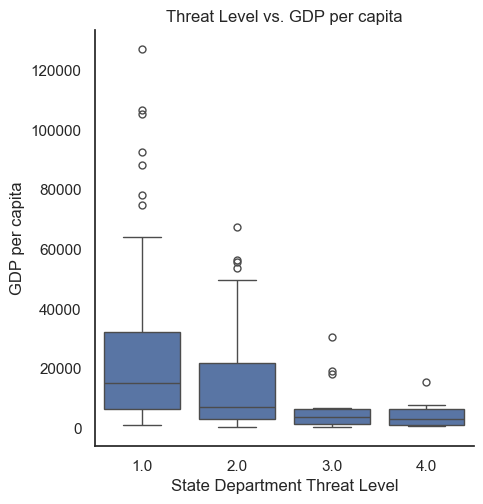

In [60]:
ThreatGDP=sns.catplot(data=df_final,
    x='Threat Level (#)',
    y='gdp_percap',
    kind='box'
    )

ThreatGDP.set(
xlabel='State Department Threat Level',
ylabel='GDP per capita',
title='Threat Level vs. GDP per capita'
)
save_graph('Threat vs. GDP per capita')




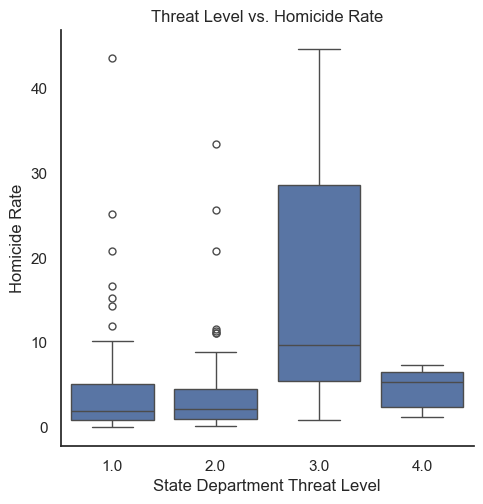

In [61]:
ThreatHomicide=sns.catplot(data=df_final,
    x='Threat Level (#)',
    y='homicide_rate',
    kind='box'
    )

ThreatHomicide.set(
xlabel='State Department Threat Level',
ylabel='Homicide Rate',
title='Threat Level vs. Homicide Rate'
)
save_graph('Threat vs. Homicide Rate')


## Q9 Relational plot

Create a relational plot by doing the following

1. Create a new variable equal to log of per-capita GDP using `np.log()`
2. Create a scatterplot with
    + log gdp on the horizontal axis
    + homicide rate on the vertical axis
    + colors of the markers corresponding to US state dept. threat level
    + size of the markers corresponds to total population



In [62]:
#Generate new variable
df_final['log GDP'] = np.log(df_final['gdp_percap'])

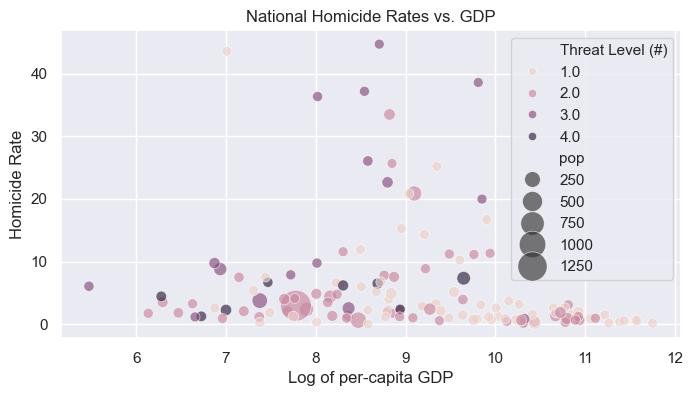

In [63]:
# Reset seaborn
sns.set_theme()
sns.set_style('ticks')
sns.set(rc={'figure.figsize':(8,4)})

# Create the figure
Scatter=sns.scatterplot(data=df_final,
    x='log GDP',
    y='homicide_rate',
    hue='Threat Level (#)',
    size='pop',sizes=(50,500),
    alpha=0.65)

# Create labels
Scatter.set(xlabel='Log of per-capita GDP',
ylabel='Homicide Rate',
title='National Homicide Rates vs. GDP')
save_graph('pov_scatter1')


## 10 Small multiples

Create a pairplot that shows the distributions of and relations between alert level, GDP per capita, and homicide rate in a single figure containing many plots.



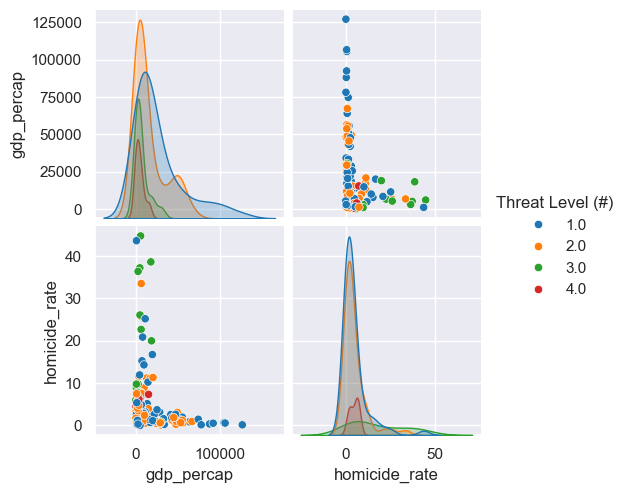

In [64]:
splot=sns.pairplot(data=df_final,
        vars=['gdp_percap','homicide_rate'],
        kind='scatter',
        diag_kind='kde',
        hue='Threat Level (#)',
        palette='tab10')

# Save to the hard drive
save_graph('pairplot4')
